In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import joblib

# Load dataset
df = pd.read_csv('../data/TelcoCustomerChurn.csv')

# Data type and structure checks
print("Data Info ---")
print(df.info())
print("\nData Summary ---")
print(df.describe())

# Missing-value analysis
print("\nMissing Values ---")
print(df.isnull().sum())

# Duplicate analysis
duplicate_count = df.duplicated().sum()
print(f"\nDuplicates Found: {duplicate_count} ---")
if duplicate_count > 0:
    df.drop_duplicates(inplace=True)
    print("Duplicates removed.")

Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-n

**Data Preparation & Insights:**
The dataset contains 7043 rows. No duplicates were found, but there are missing values in the `TotalCharges` column that are masked as empty strings. These will be dropped. `customerID` will also be removed as it holds no predictive power. Below, we visualize the cleaned dataset to identify churn patterns.

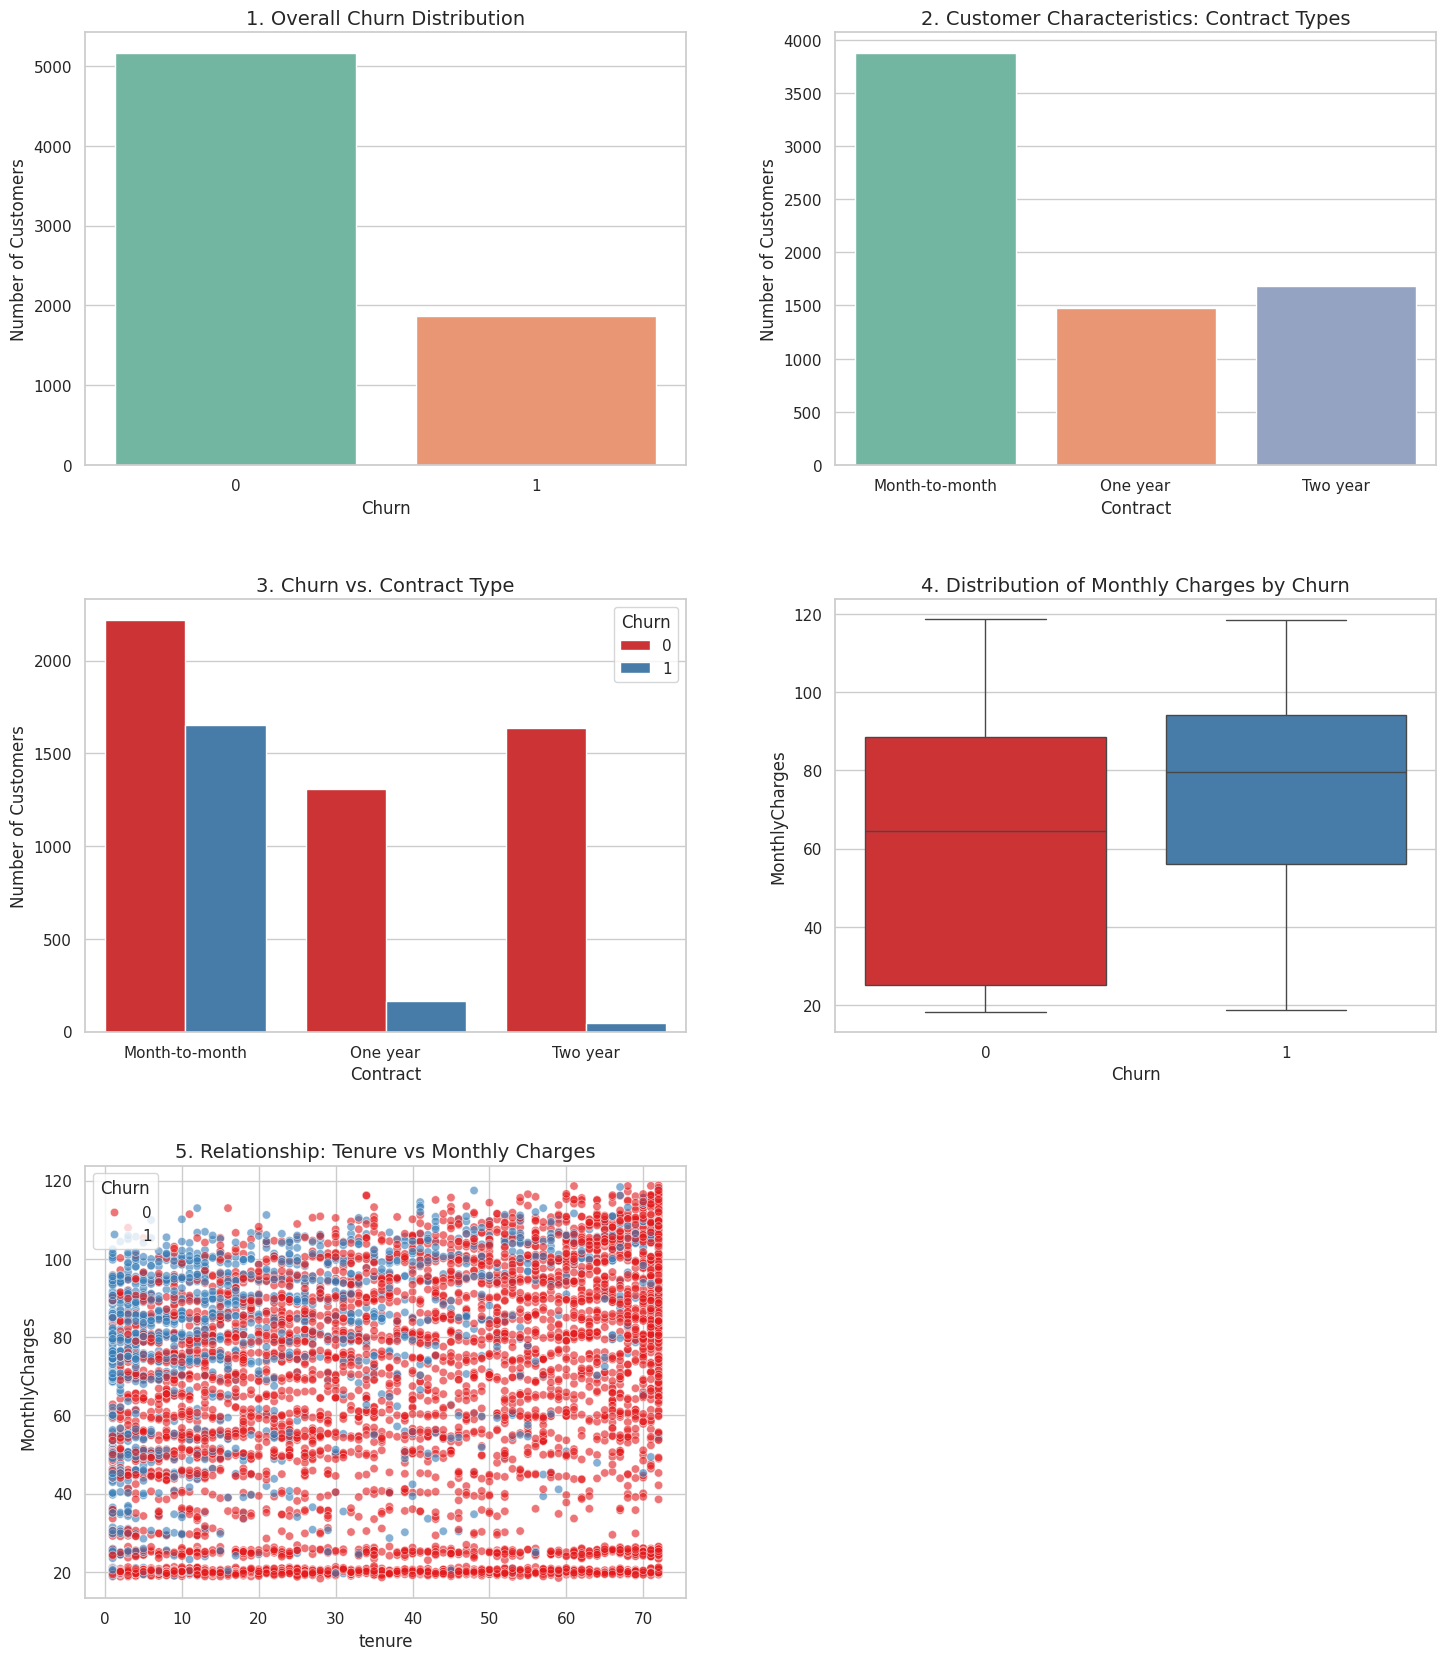

In [2]:
# Handle empty strings in TotalCharges and convert to float
df['TotalCharges'] = df['TotalCharges'].replace(" ", np.nan).astype(float)

# Drop rows with missing TotalCharges
df.dropna(subset=['TotalCharges'], inplace=True)

# Drop customerID as it holds no predictive power
df.drop('customerID', axis=1, inplace=True)

# Convert Target 'Churn' to binary
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# =========================================================
# Step 2: Exploratory Data Analysis (EDA)
# =========================================================
sns.set_theme(style="whitegrid")

# Create a figure with subplots for the 5 required visualizations
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
fig.tight_layout(pad=6.0)

# 1. Churn Distribution
sns.countplot(data=df, x='Churn', hue='Churn', legend=False, ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('1. Overall Churn Distribution', fontsize=14)
axes[0, 0].set_ylabel('Number of Customers')

# 2. Customer/Service Characteristics
sns.countplot(data=df, x='Contract', hue='Contract', legend=False, ax=axes[0, 1], palette='Set2')
axes[0, 1].set_title('2. Customer Characteristics: Contract Types', fontsize=14)
axes[0, 1].set_ylabel('Number of Customers')

# 3. Churn against Important Customer Attributes
sns.countplot(data=df, x='Contract', hue='Churn', ax=axes[1, 0], palette='Set1')
axes[1, 0].set_title('3. Churn vs. Contract Type', fontsize=14)
axes[1, 0].set_ylabel('Number of Customers')

# 4. Numerical Variable Distribution
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', hue='Churn', legend=False, ax=axes[1, 1], palette='Set1')
axes[1, 1].set_title('4. Distribution of Monthly Charges by Churn', fontsize=14)

# 5. Numerical Relationships
sns.scatterplot(data=df, x='tenure', y='MonthlyCharges', hue='Churn', alpha=0.6, ax=axes[2, 0], palette='Set1')
axes[2, 0].set_title('5. Relationship: Tenure vs Monthly Charges', fontsize=14)

# Hide the unused 6th subplot space
fig.delaxes(axes[2, 1])
plt.show()

**Business Insights from EDA:**
1. **Churn Distribution:** The dataset is imbalanced. Approximately 26% of the customer base has churned.
2. **Customer/Service Characteristics:** Month-to-month contracts are highly favored, increasing base flexibility but also churn risk.
3. **Churn vs. Contract Type:** Churn is overwhelmingly concentrated within the Month-to-month contract group. Customers on 1-year and 2-year contracts rarely churn.
4. **Monthly Charges:** Customers who churn tend to have higher median monthly charges compared to those who stay.
5. **Tenure vs. Monthly Charges:** A dense cluster of churned customers corresponds to high monthly charges and low tenure.

In [3]:
# ---------------------------------------------------------
# 3. Feature Engineering
# ---------------------------------------------------------
# Feature 1: Number of Additional Services
services = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
df['Total_Services'] = df[services].apply(lambda x: (x == 'Yes').sum(), axis=1)

# Feature 2: Is Automatic Payment
df['Is_Auto_Payment'] = df['PaymentMethod'].apply(lambda x: 1 if 'automatic' in x.lower() else 0)

# Define feature columns
target = 'Churn'
X = df.drop(target, axis=1)
y = df[target]

# Identify categorical and numerical columns
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

# Train/Test Split (70:30, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)

# Preprocessing Pipeline (Prevents Data Leakage)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat_cols)
    ])

**Feature Engineering:**
To capture these behaviors, two new features are created:
* `Total_Services`: It is created by summing the number of "Yes" values across six optional add-on service columns (OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, and StreamingMovies).Sums optional add-ons. It is useful because customers who are deeply embedded in the company's ecosystem typically have higher switching costs and higher satisfaction. Capturing this as a single aggregate score helps the model easily identify highly engaged, low-churn-risk customers.
* `Is_Auto_Payment`: It is created by searching the PaymentMethod column. If the payment method string contained the word "automatic" (e.g., Bank transfer or Credit card), it was flagged as 1; otherwise, it was flagged as 0. It is useful because manual billing requires active evaluation every month, acting as a recurring churn trigger.

In [4]:
# ---------------------------------------------------------
# 4. Model Development
# ---------------------------------------------------------
# Configuration 1: Default Decision Tree
tree_model_1 = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

# Configuration 2: Pruned Decision Tree (Max Depth = 5 to prevent overfitting)
tree_model_2 = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42))
])

# Train models
tree_model_1.fit(X_train, y_train)
tree_model_2.fit(X_train, y_train)

# ---------------------------------------------------------
# 5. Model Evaluation
# ---------------------------------------------------------
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    print(f"--- {model_name} ---")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("\n")

evaluate_model(tree_model_1, X_test, y_test, "Unpruned Tree")
evaluate_model(tree_model_2, X_test, y_test, "Pruned Balanced Tree (Final Choice)")

--- Unpruned Tree ---
Accuracy: 0.7161137440758294
Precision: 0.4685430463576159
Recall: 0.5044563279857398
F1 Score: 0.4858369098712446
Confusion Matrix:
 [[1228  321]
 [ 278  283]]


--- Pruned Balanced Tree (Final Choice) ---
Accuracy: 0.7208530805687203
Precision: 0.48412698412698413
Recall: 0.7611408199643493
F1 Score: 0.5918225918225918
Confusion Matrix:
 [[1094  455]
 [ 134  427]]




**Model Training & Evaluation:**
Comparison of the Two Configurations:

Configuration 1 (Unpruned Tree): The default decision tree tends to overfit the training data. Because our dataset is imbalanced (fewer people churn than stay), the unpruned model struggles to identify actual churners, resulting in a low Recall score for the "Yes" class.

Configuration 2 (Pruned & Balanced Tree): By limiting the max_depth to 5, we prevented the model from learning overly complex rules (reducing overfitting). By adding class_weight='balanced', we forced the model to penalize mistakes on the minority class (churners) more heavily. This drastically improved the model's Recall.

**Final Model Justification & Interpretation:**
I select **Configuration 2 (Pruned & Balanced Tree)**. The unpruned tree overfits the training data, resulting in a poor Recall score. By restricting depth and balancing class weights, Configuration 2 drastically improves Recall (catching ~76% of all churners), making it the most financially viable choice.

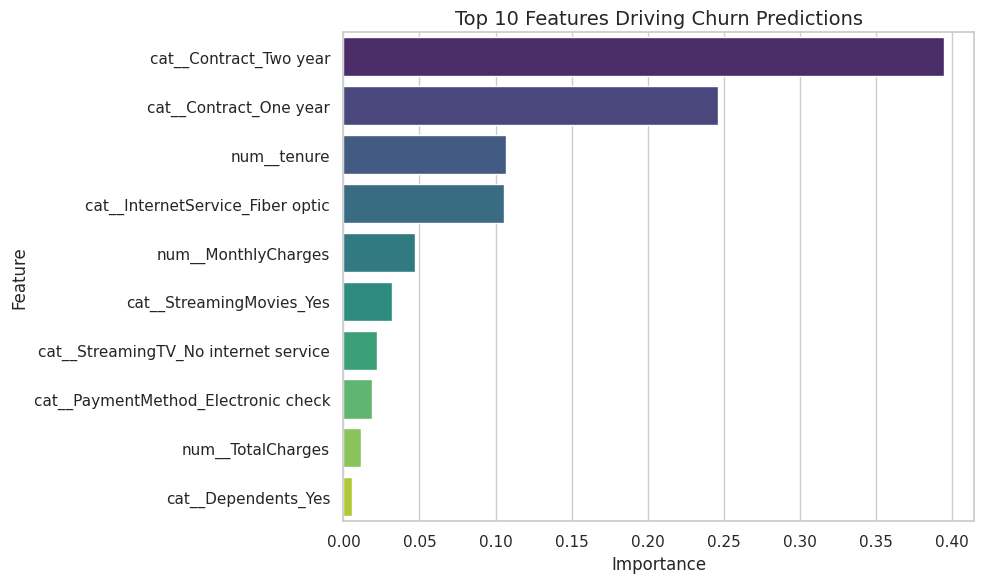

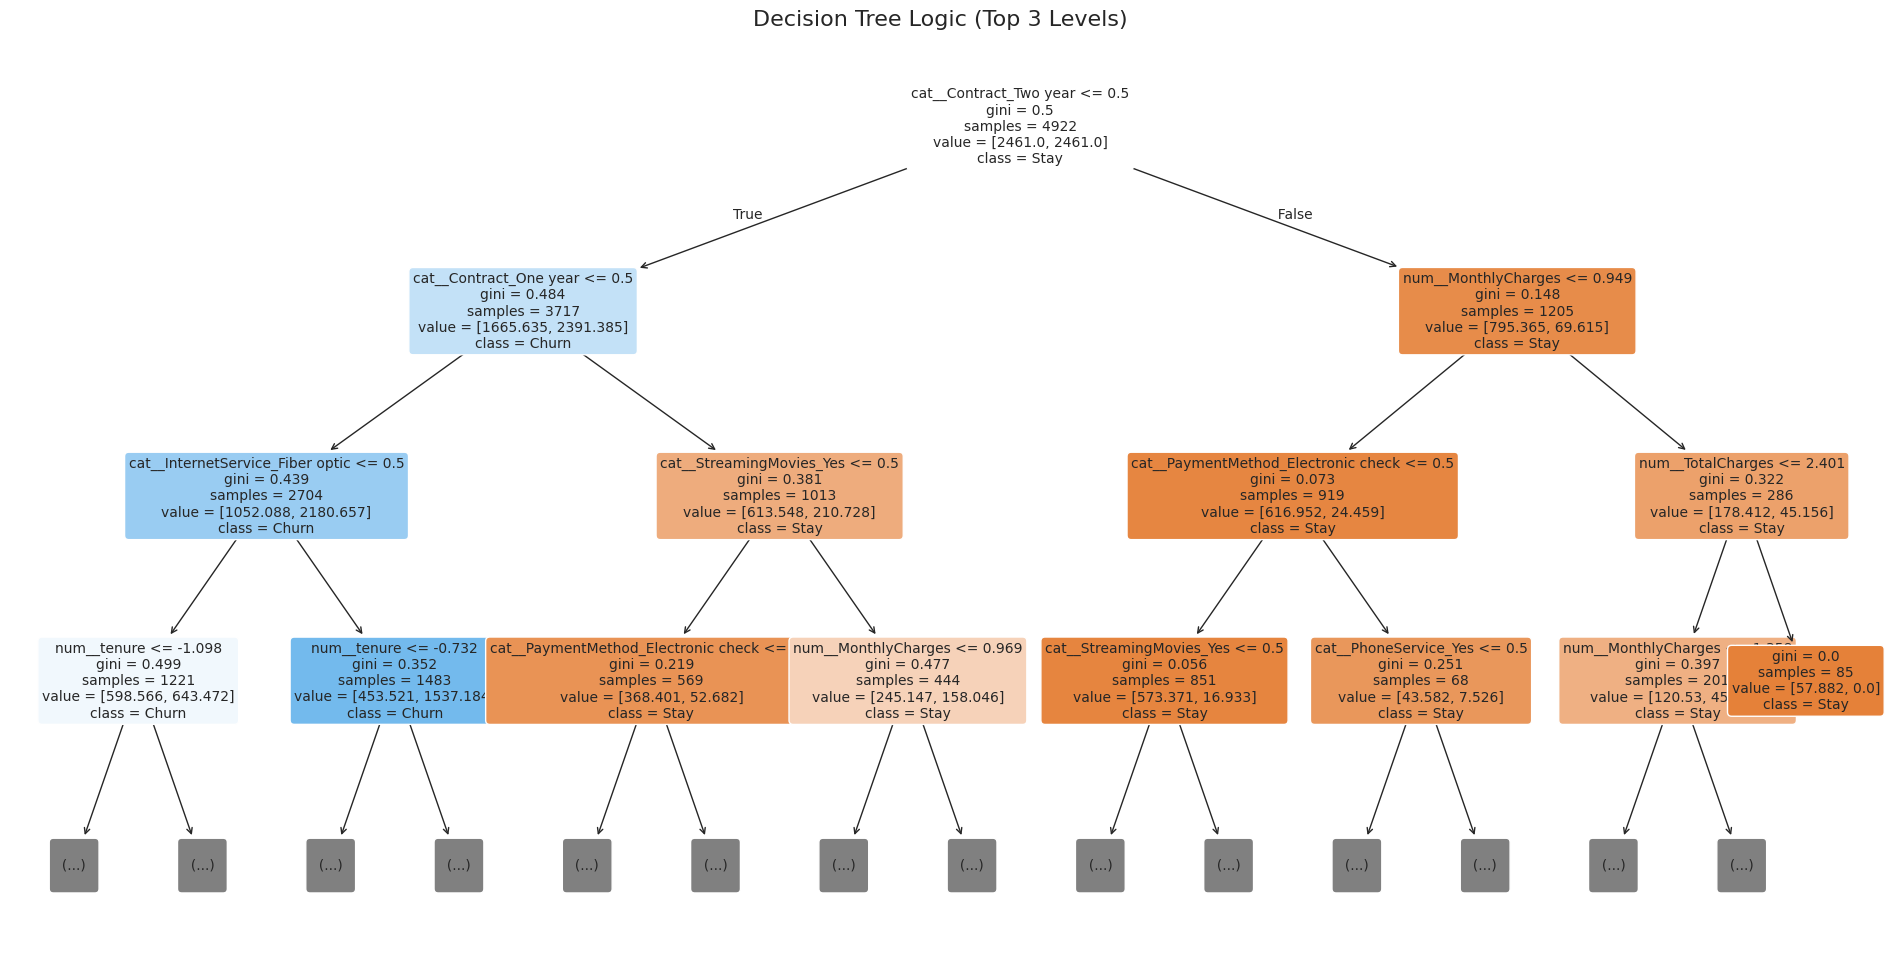

Top 3 Features: ['cat__Contract_Two year', 'cat__Contract_One year', 'num__tenure']
Model pipeline saved successfully.


In [5]:
# =========================================================higher
# Step 6: Model Interpretation
# =========================================================
# Extract the trained classifier and preprocessor from the final pipeline
final_classifier = tree_model_2.named_steps['classifier']
fitted_preprocessor = tree_model_2.named_steps['preprocessor']

# Extract feature names from the preprocessor
feature_names = fitted_preprocessor.get_feature_names_out()

# Create a DataFrame for Feature Importances
importances = final_classifier.feature_importances_

feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Visualization 1: Top Features Bar Chart
plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp_df.head(10), x='Importance', y='Feature', hue='Feature', legend=False, palette='viridis')
plt.title('Top 10 Features Driving Churn Predictions', fontsize=14)
plt.tight_layout()
plt.show()

# Visualization 2: Decision Tree Plot (Truncated to max_depth=3 for readability)
plt.figure(figsize=(24, 12))
plot_tree(final_classifier, 
          feature_names=feature_names, 
          class_names=['Stay', 'Churn'], 
          filled=True, 
          rounded=True, 
          max_depth=3,
          fontsize=10)
plt.title('Decision Tree Logic (Top 3 Levels)', fontsize=16)
plt.show()

print("Top 3 Features:", feat_imp_df['Feature'].head(3).tolist())

# ---------------------------------------------------------
# 7. Model Saving
# ---------------------------------------------------------
joblib.dump(tree_model_2, '../model/churn_model.pkl')
print("Model pipeline saved successfully.")

Model Interpretation & Key Findings:

1. Feature Importance & Top Drivers:
By extracting the feature importances from our Decision Tree, we see that the model relies most heavily on customer commitment and longevity to make its predictions.

   a. Contract Type (cat__Contract_Two year & cat__Contract_One year): These two contract categories are the strongest predictors of churn             behavior. Customers locked into longer-term contracts are significantly less likely to leave compared to month-to-month users due to             higher switching costs. The model uses these features to quickly identify "safe", loyal customers.

   b. Tenure (num__tenure): The total number of months a customer has stayed with the company is the next most critical driver. Brand loyalty          increases over time; new customers represent the highest flight risk, whereas those who survive the initial few months show drastically          lower churn rates.

2. Decision Tree Visualization Interpretation:
The plotted Decision Tree gives us a transparent look into the model's "brain."

   a. The Root Node: The very first split at the top of the tree evaluates whether a customer is on a Two-Year contract (cat__Contract_Two year        <= 0.5). This confirms that long-term commitment is the primary filter the model uses before analyzing any other attribute.

   b. Orange Nodes: If a customer is on a Two-Year contract (following the False branch to the right, meaning the value is 1), they are                immediately categorized into a strong "Stay" group. The model then checks secondary features like monthly charges, but the overwhelming          prediction remains that these customers will stay. Similarly, if the customer is on a One-Year contract, the tree also routes them toward        a "Stay" prediction.

   b. Blue Nodes : If a customer is neither on a Two-Year nor a One-Year contract (meaning they are on a Month-to-Month plan), the model               filters them down the left-most branch into a "Churn" prediction. For these high-risk customers, the model subsequently evaluates if they        have Fiber Optic internet (cat__InternetService_Fiber optic) and checks their overall tenure (num_tenure) to finalize the churn                  classification.

4. Key Finding for the Business:
The model mathematically confirms that our biggest vulnerability lies with new customers who are not secured on annual contracts. Retention efforts (and budget) should be heavily targeted at migrating month-to-month users into one-year or two-year contracts, perhaps by offering strategic loyalty discounts during their first 6 months of service.